In [1]:
import pandas as pd 

In [2]:
import seaborn as sns

In [3]:
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('data.csv', encoding='latin1')

In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
df['total_revenue'] = df['UnitPrice'] * df['Quantity']

In [11]:
country_sales = df.groupby('Country')['total_revenue'].sum().sort_values(ascending=False)

In [14]:
print(country_sales.head(10))

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: total_revenue, dtype: float64


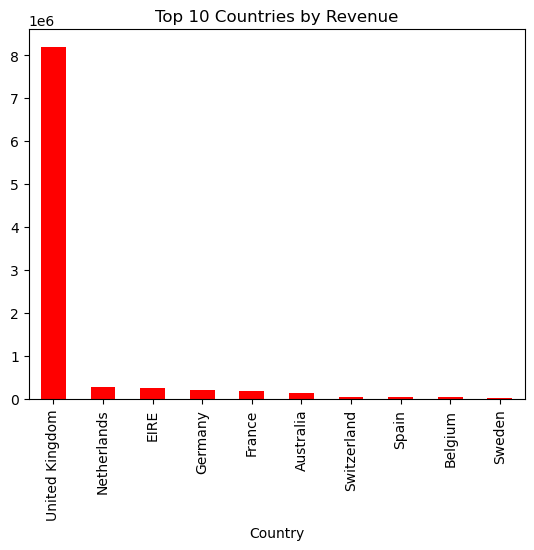

In [17]:
country_sales.head(10).plot(kind='bar', color='red')
plt.title("Top 10 Countries by Revenue")
plt.show()

In [24]:
top_products = df.groupby('Description')['total_revenue'].sum().sort_values(ascending=False)

In [25]:
print(top_products.head(10))

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: total_revenue, dtype: float64


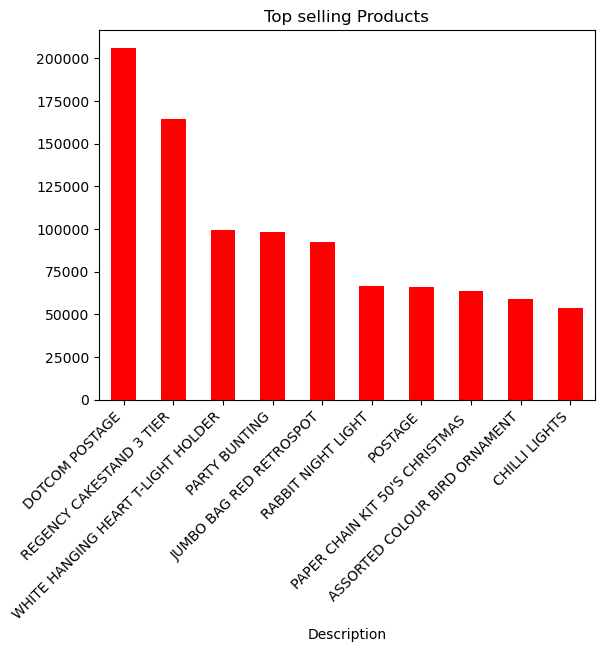

In [29]:
top_products.head(10).plot(kind='bar', color='red')
plt.title("Top selling Products")
plt.xticks(rotation=45, ha='right')
plt.show()

In [48]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [49]:
df['Month'] = df['InvoiceDate'].dt.month_name()

In [50]:
monthly_sales = df.groupby('Month')['total_revenue'].sum()

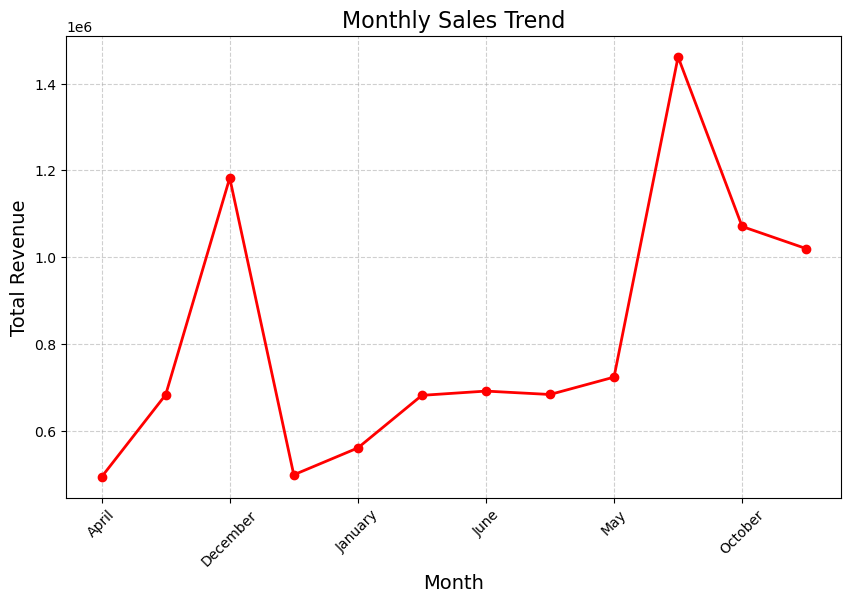

In [51]:
plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='line', marker='o', color='red', linewidth=2)
plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Total Revenue", fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [53]:
top_customers = df.groupby('CustomerID')['total_revenue'].sum().sort_values(ascending=False)

In [54]:
print(top_customers.head(10))

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: total_revenue, dtype: float64


In [75]:
order_value = df.groupby('InvoiceNo')['total_revenue'].sum()

In [76]:
aov = order_value.mean()

In [77]:
print("Average order value:", aov)

Average order value: 376.3609240926641


In [78]:
df['Hour'] = df['InvoiceDate'].dt.hour

In [79]:
hourly_sales = df.groupby('Hour')['total_revenue'].sum()

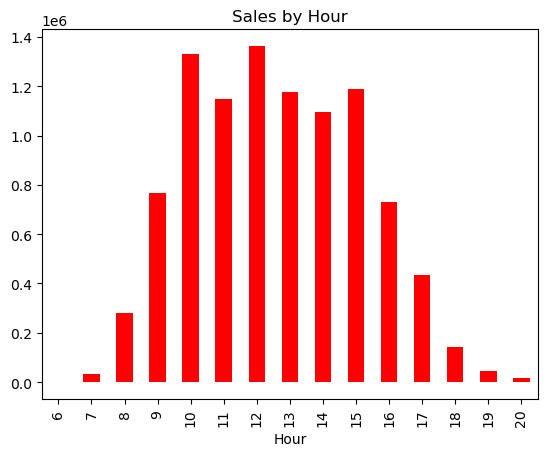

In [82]:
hourly_sales.plot(kind='bar', color='red')
plt.title("Sales by Hour")
plt.show()